In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, time

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    cross_val_predict, train_test_split
)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

DATA_DIR = '/content/'

# ── Load data ──────────────────────────────────────────────────────────────
X_letters       = np.load(os.path.join(DATA_DIR, "letters_keypoints.npy"))
y_letters       = np.load(os.path.join(DATA_DIR, "letters_labels.npy"))
letters_encoder = joblib.load(os.path.join(DATA_DIR, "letters_label_encoder.pkl"))

X_numbers       = np.load(os.path.join(DATA_DIR, "numbers_keypoints.npy"))
y_numbers       = np.load(os.path.join(DATA_DIR, "numbers_labels.npy"))
numbers_encoder = joblib.load(os.path.join(DATA_DIR, "numbers_label_encoder.pkl"))

print("Letters :", X_letters.shape, "| classes:", len(letters_encoder.classes_))
print("Numbers :", X_numbers.shape, "| classes:", len(numbers_encoder.classes_))

Letters : (6540, 151) | classes: 31
Numbers : (579, 151) | classes: 11


# Model Dictionaries

In [2]:
letters_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=25, max_features="sqrt",
        min_samples_leaf=2, class_weight="balanced",
        n_jobs=-1, random_state=42
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(512, 256, 128, 64),
            activation="relu", solver="adam",
            alpha=0.0005, learning_rate_init=0.001,
            learning_rate="adaptive", early_stopping=True,
            validation_fraction=0.10, n_iter_no_change=15,
            max_iter=600, random_state=42
        ))
    ]),
    "XGBoost": XGBClassifier(
        objective="multi:softmax", num_class=31,
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=42,
        eval_metric="mlogloss"
    )
}

numbers_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=15, max_features="sqrt",
        min_samples_leaf=4, class_weight="balanced",
        n_jobs=-1, random_state=42
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu", solver="adam",
            alpha=0.005, learning_rate_init=0.001,
            learning_rate="adaptive", early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=10,
            max_iter=500, random_state=42
        ))
    ]),
    "XGBoost": XGBClassifier(
        objective="multi:softmax", num_class=11,
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        gamma=0.2, reg_alpha=0.5, reg_lambda=1.0,
        tree_method="hist", n_jobs=-1, random_state=42,
        eval_metric="mlogloss"
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [3]:
def evaluate_model(name, model,
                   X_train, y_train,
                   X_test,  y_test,
                   X_full,  y_full,
                   encoder, task):

    print(f"\n{'='*55}")
    print(f"  MODEL: {name}  |  task: {task.upper()}")
    print(f"{'='*55}")

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test,  y_test)
    print(f"Train accuracy : {train_acc:.4f}")
    print(f"Test  accuracy : {test_acc:.4f}")
    print(f"Overfit gap    : {train_acc - test_acc:.4f}")

    y_pred = model.predict(X_test)
    print("\nTest classification report:\n")
    print(classification_report(
        y_test, y_pred,
        target_names=encoder.classes_
    ))

    # Cross-validation
    print("── 5-Fold CV ──")
    cv_scores = cross_val_score(
        model, X_full, y_full, cv=skf, n_jobs=-1
    )
    print(f"  Scores : {np.round(cv_scores, 4)}")
    print(f"  Mean   : {np.mean(cv_scores):.4f}")
    print(f"  Std    : {np.std(cv_scores):.4f}")

    y_pred_cv = cross_val_predict(
        model, X_full, y_full, cv=skf, n_jobs=-1
    )
    print("\nCV classification report:\n")
    print(classification_report(
        y_full, y_pred_cv,
        target_names=encoder.classes_
    ))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(14, 12))
    ConfusionMatrixDisplay.from_predictions(
        y_full, y_pred_cv,
        display_labels=encoder.classes_,
        xticks_rotation="vertical",
        cmap="Blues", ax=ax
    )
    plt.title(f"Confusion matrix — {name} [{task}] (5-fold CV)")
    plt.tight_layout()
    plt.savefig(f"cm_{name}_{task}.png", dpi=150)
    plt.show()

    # Save model
    path = f"models/{name}_{task}.pkl"
    os.makedirs("models", exist_ok=True)
    joblib.dump(model, path)
    print(f"Saved: {path}")

    return {
        "model"    : name,
        "task"     : task,
        "train_acc": train_acc,
        "test_acc" : test_acc,
        "cv_mean"  : np.mean(cv_scores),
        "cv_std"   : np.std(cv_scores)
    }


def measure_speed(model, X_sample, n_runs=200):
    start = time.time()
    for _ in range(n_runs):
        model.predict(X_sample)
    elapsed = time.time() - start
    t = elapsed / n_runs
    return t, 1.0 / t

In [4]:
# ── run_task ───────────────────────────────────────────────────────────────
def run_task(X, y, encoder, task, models_dict):
    """
    Split → train all models → speed benchmark → summary table.
    """
    print(f"\n{'#'*60}")
    print(f"#  TASK: {task.upper()}")
    print(f"#  {X.shape[0]} samples | "
          f"{len(encoder.classes_)} classes | "
          f"{X.shape[1]} features")
    print(f"{'#'*60}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

    results = []
    for name, model in models_dict.items():
        r = evaluate_model(
            name, model,
            X_train, y_train,
            X_test,  y_test,
            X,       y,
            encoder, task
        )
        results.append(r)

    # Speed benchmark
    X_sample = X_test[:1]
    print(f"\n── Inference speed (single sample, 200 runs) ──")
    print(f"{'Model':20s}  {'ms/pred':>10}  {'FPS':>8}")
    print("-" * 44)
    for name, model in models_dict.items():
        t, fps = measure_speed(model, X_sample)
        print(f"  {name:18s}  {t*1000:8.3f} ms  {fps:8.1f}")

    # Summary
    print(f"\n── Results summary — {task} ──")
    print(f"{'Model':20s}  {'Train':>7}  {'Test':>7}  "
          f"{'CV Mean':>9}  {'CV Std':>8}")
    print("-" * 58)
    for r in results:
        print(f"  {r['model']:18s}  {r['train_acc']:7.4f}  "
              f"{r['test_acc']:7.4f}  {r['cv_mean']:9.4f}  "
              f"{r['cv_std']:8.4f}")

    return results


############################################################
#  TASK: LETTERS
#  6540 samples | 31 classes | 151 features
############################################################
Train: 5232  |  Test: 1308

  MODEL: RandomForest  |  task: LETTERS
Train accuracy : 0.9979
Test  accuracy : 0.9381
Overfit gap    : 0.0598

Test classification report:

              precision    recall  f1-score   support

         Ain       1.00      0.95      0.97        41
          Al       1.00      0.96      0.98        47
        Alef       1.00      0.98      0.99        46
         Beh       0.85      0.92      0.88        50
         Dad       0.93      0.89      0.91        45
         Dal       1.00      1.00      1.00        39
         Feh       0.91      0.98      0.94        43
       Ghain       1.00      1.00      1.00        38
         Hah       0.92      0.92      0.92        39
         Heh       0.98      0.98      0.98        44
        Jeem       0.91      0.88      0.90        

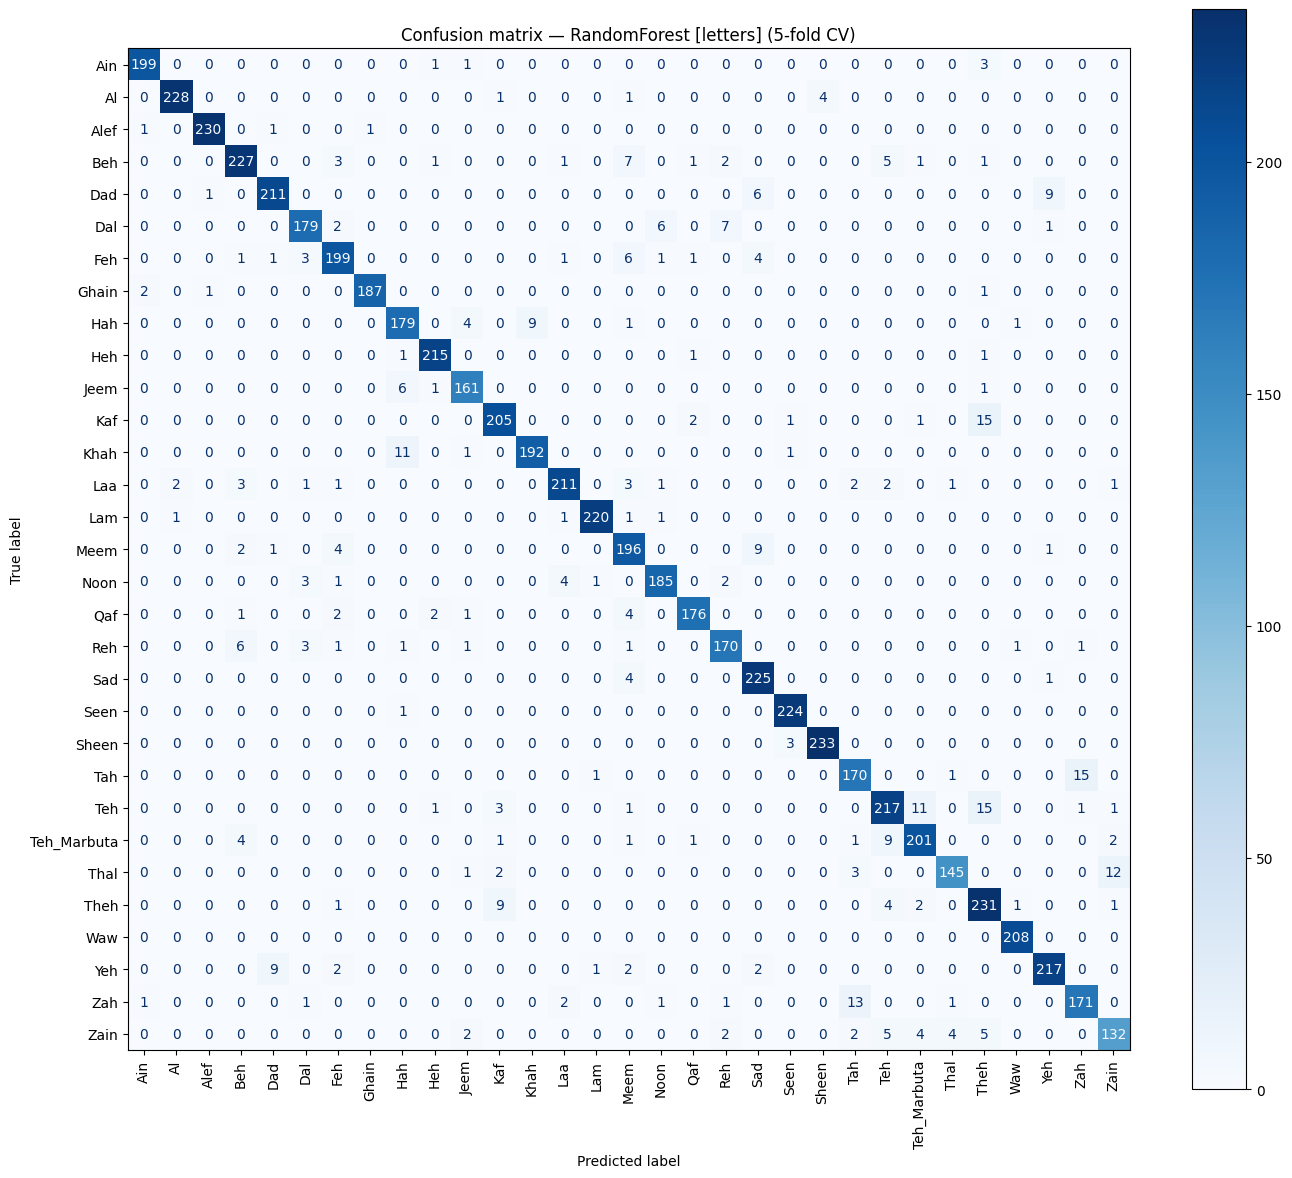

Saved: models/RandomForest_letters.pkl

  MODEL: MLP  |  task: LETTERS
Train accuracy : 0.9962
Test  accuracy : 0.9564
Overfit gap    : 0.0398

Test classification report:

              precision    recall  f1-score   support

         Ain       1.00      0.95      0.97        41
          Al       1.00      0.98      0.99        47
        Alef       1.00      1.00      1.00        46
         Beh       0.92      0.96      0.94        50
         Dad       0.98      0.93      0.95        45
         Dal       0.97      0.97      0.97        39
         Feh       0.89      0.95      0.92        43
       Ghain       0.97      1.00      0.99        38
         Hah       0.97      0.95      0.96        39
         Heh       0.96      0.98      0.97        44
        Jeem       0.97      1.00      0.99        34
         Kaf       0.95      0.91      0.93        45
        Khah       0.98      1.00      0.99        41
         Laa       0.98      0.93      0.96        46
         Lam    

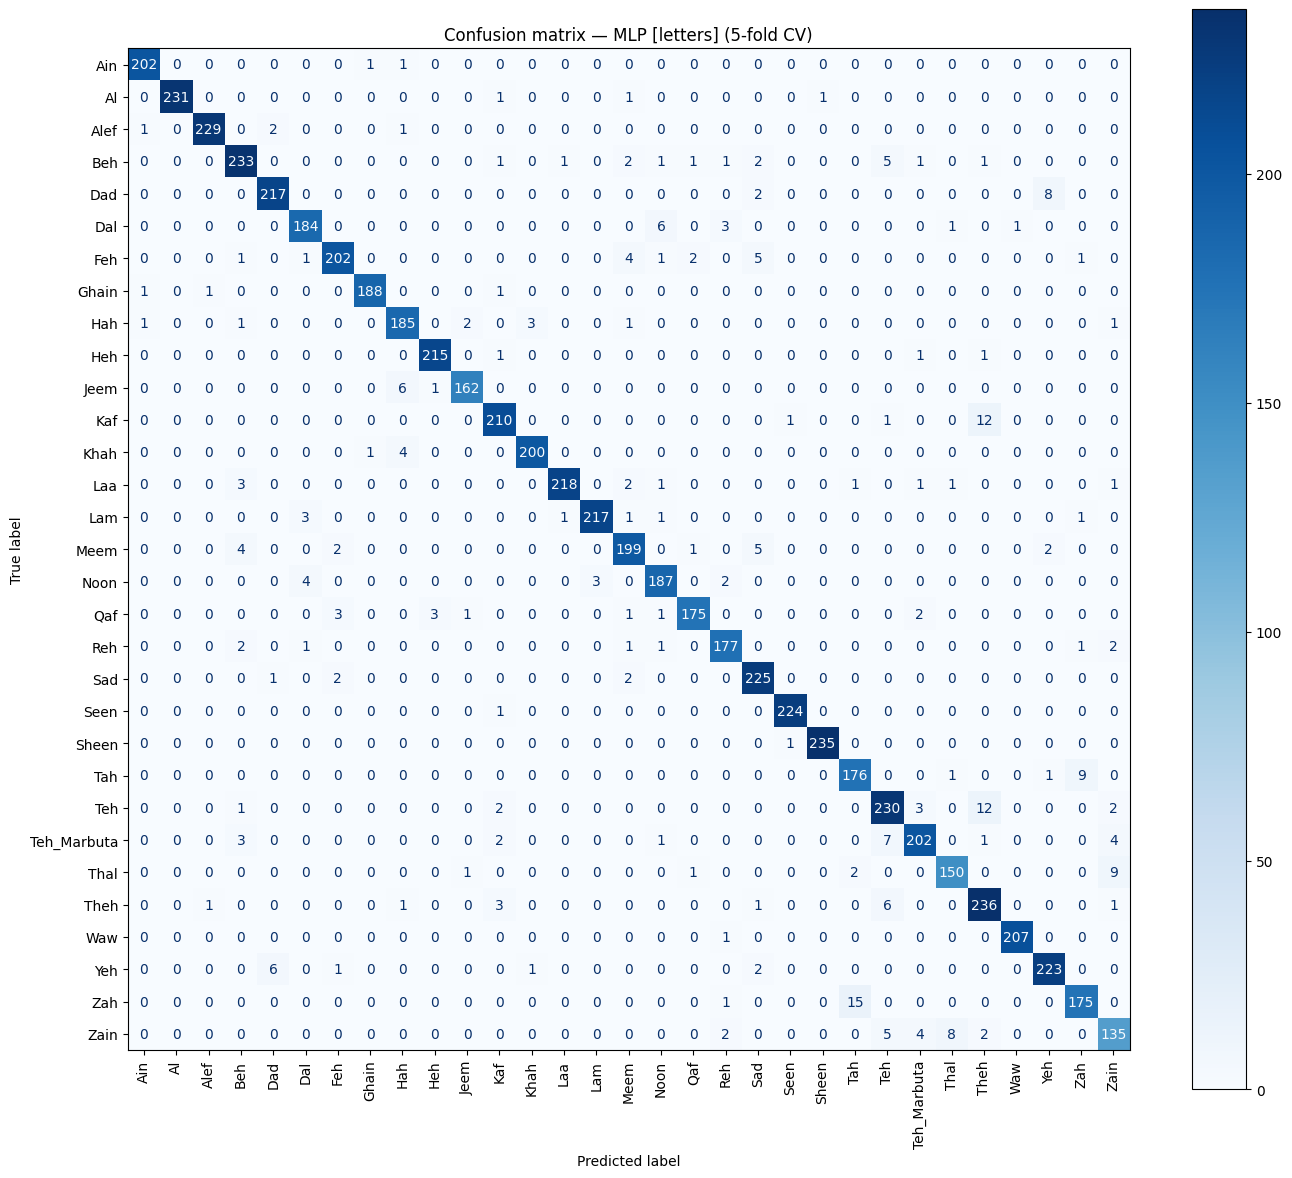

Saved: models/MLP_letters.pkl

  MODEL: XGBoost  |  task: LETTERS
Train accuracy : 0.9998
Test  accuracy : 0.9511
Overfit gap    : 0.0487

Test classification report:

              precision    recall  f1-score   support

         Ain       1.00      0.98      0.99        41
          Al       0.98      0.98      0.98        47
        Alef       0.98      0.98      0.98        46
         Beh       0.94      0.92      0.93        50
         Dad       0.98      0.91      0.94        45
         Dal       0.95      1.00      0.97        39
         Feh       0.88      0.98      0.92        43
       Ghain       0.97      0.97      0.97        38
         Hah       0.97      0.95      0.96        39
         Heh       0.98      1.00      0.99        44
        Jeem       0.94      0.94      0.94        34
         Kaf       0.97      0.87      0.92        45
        Khah       0.98      1.00      0.99        41
         Laa       0.98      0.96      0.97        46
         Lam       0.

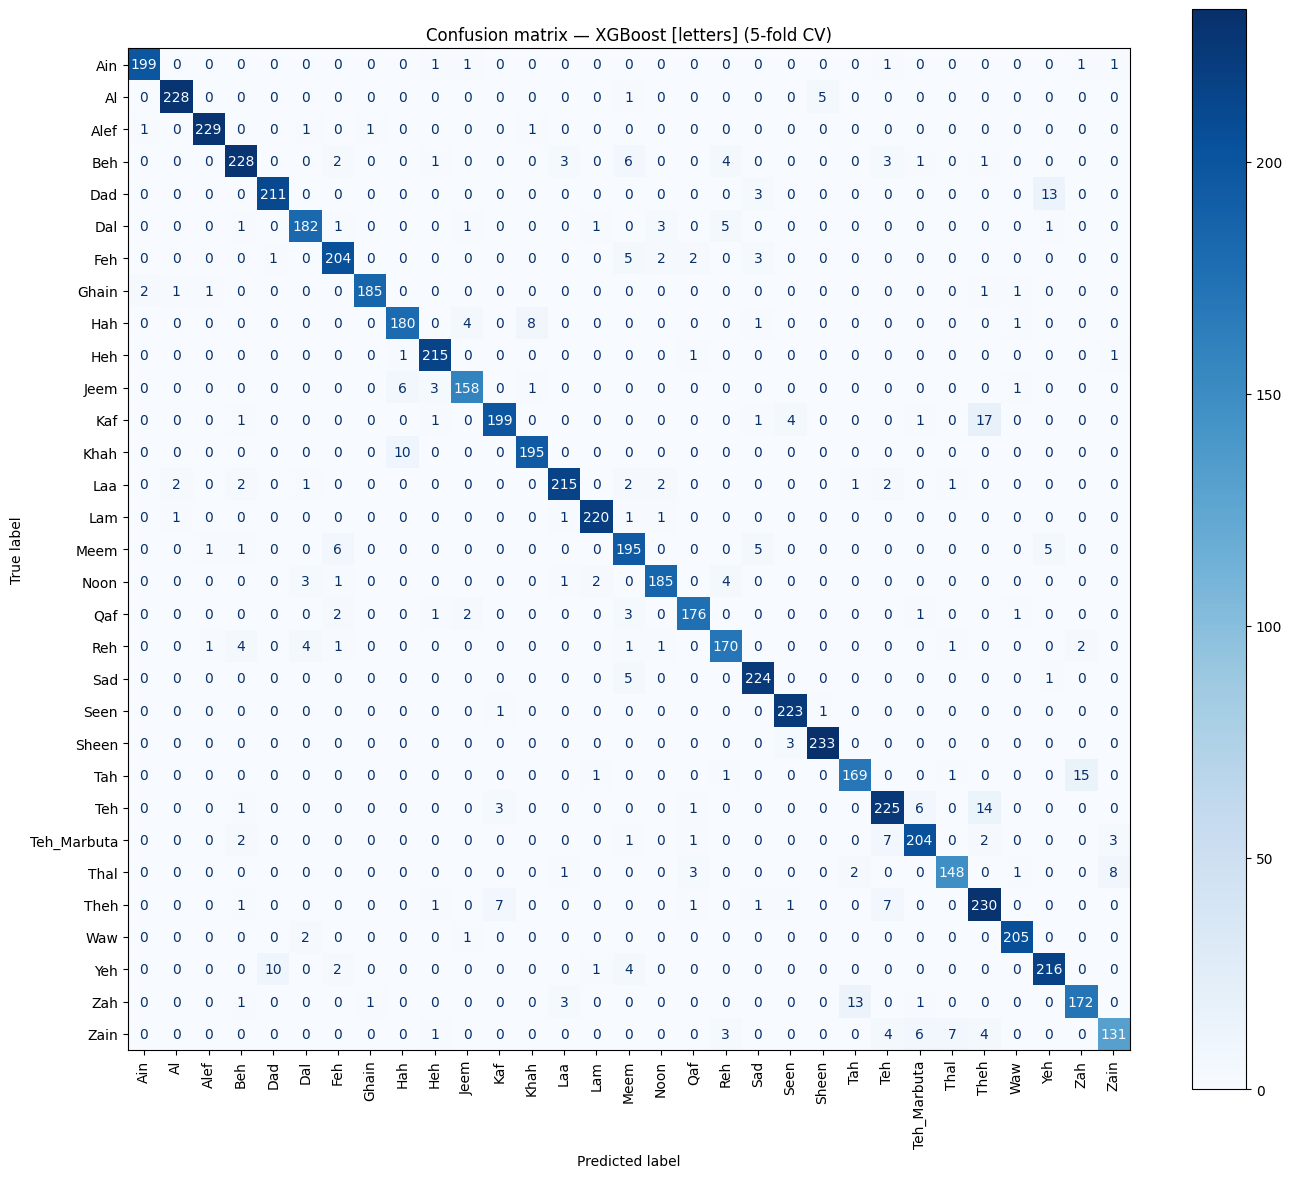

Saved: models/XGBoost_letters.pkl

── Inference speed (single sample, 200 runs) ──
Model                    ms/pred       FPS
--------------------------------------------
  RandomForest          64.508 ms      15.5
  MLP                    0.705 ms    1418.5
  XGBoost                2.268 ms     440.9

── Results summary — letters ──
Model                   Train     Test    CV Mean    CV Std
----------------------------------------------------------
  RandomForest         0.9979   0.9381     0.9394    0.0029
  MLP                  0.9962   0.9564     0.9555    0.0036
  XGBoost              0.9998   0.9511     0.9410    0.0048


In [5]:
# ── Run ────────────────────────────────────────────────────────────────────
letters_results = run_task(
    X_letters, y_letters, letters_encoder,
    task="letters", models_dict=letters_models
)


############################################################
#  TASK: NUMBERS
#  579 samples | 11 classes | 151 features
############################################################
Train: 463  |  Test: 116

  MODEL: RandomForest  |  task: NUMBERS
Train accuracy : 0.9849
Test  accuracy : 0.8793
Overfit gap    : 0.1056

Test classification report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       0.90      0.90      0.90        10
          10       1.00      0.83      0.91        12
           2       0.78      0.70      0.74        10
           3       0.77      0.91      0.83        11
           4       0.80      0.80      0.80        10
           5       1.00      1.00      1.00        11
           6       0.91      1.00      0.95        10
           7       0.91      0.83      0.87        12
           8       0.89      0.80      0.84        10
           9       1.00      0.91      0.95        11


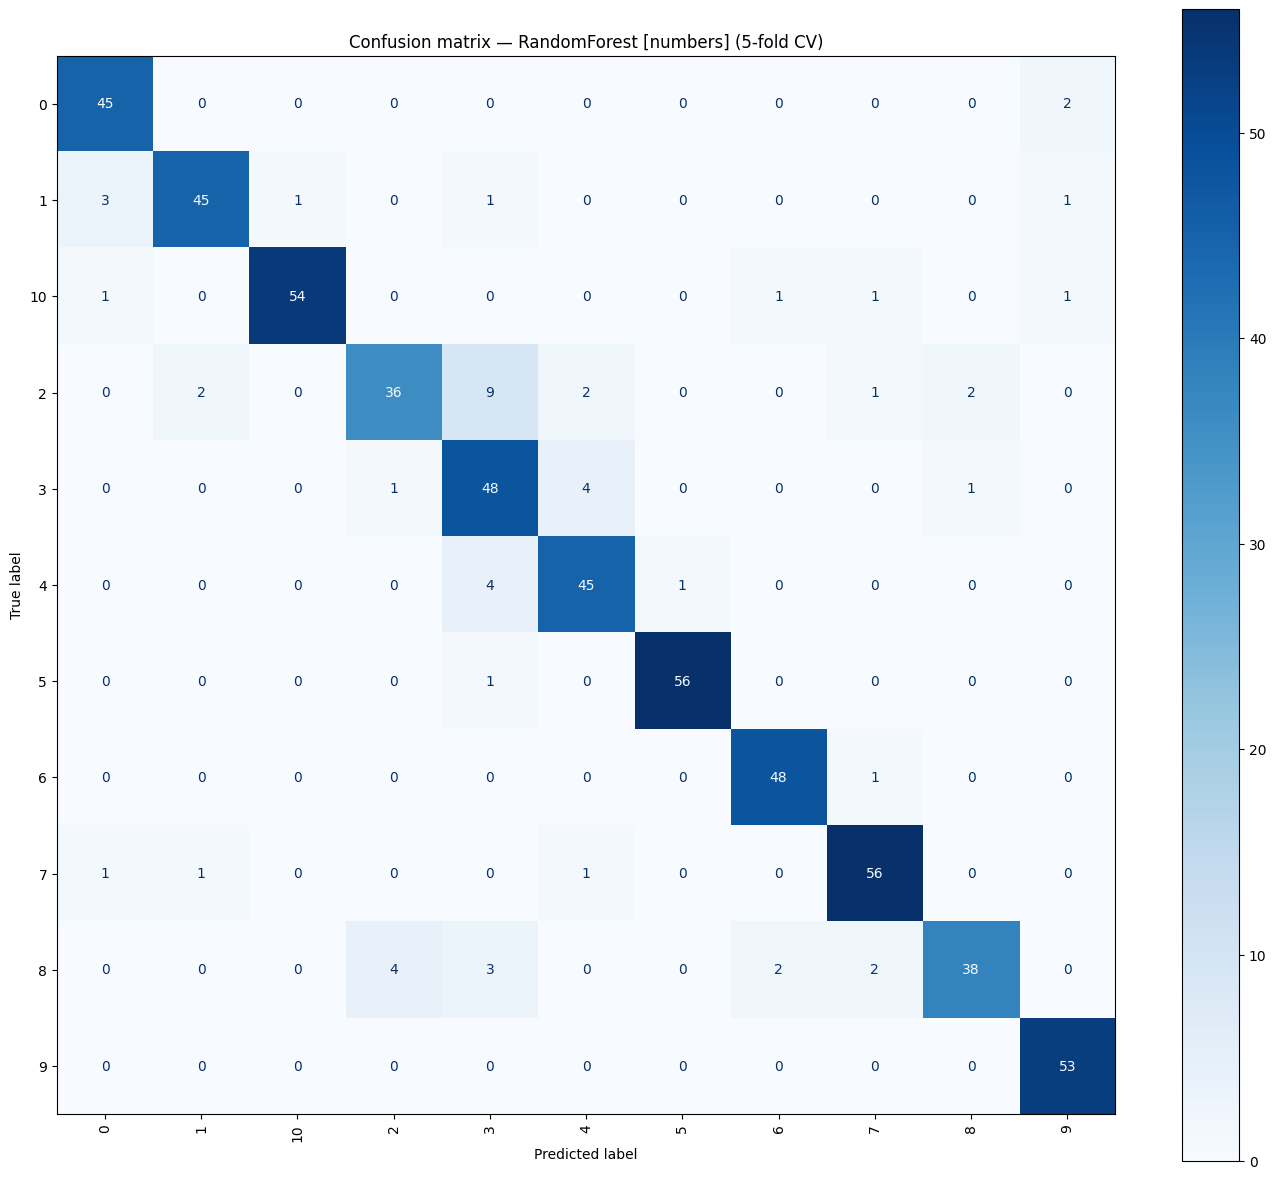

Saved: models/RandomForest_numbers.pkl

  MODEL: MLP  |  task: NUMBERS
Train accuracy : 0.9957
Test  accuracy : 0.8879
Overfit gap    : 0.1077

Test classification report:

              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.90      0.95        10
          10       1.00      0.75      0.86        12
           2       0.80      0.80      0.80        10
           3       0.77      0.91      0.83        11
           4       0.80      0.80      0.80        10
           5       0.92      1.00      0.96        11
           6       0.91      1.00      0.95        10
           7       1.00      0.83      0.91        12
           8       0.90      0.90      0.90        10
           9       0.91      0.91      0.91        11

    accuracy                           0.89       116
   macro avg       0.89      0.89      0.89       116
weighted avg       0.90      0.89      0.89       116

── 5-Fold CV ─

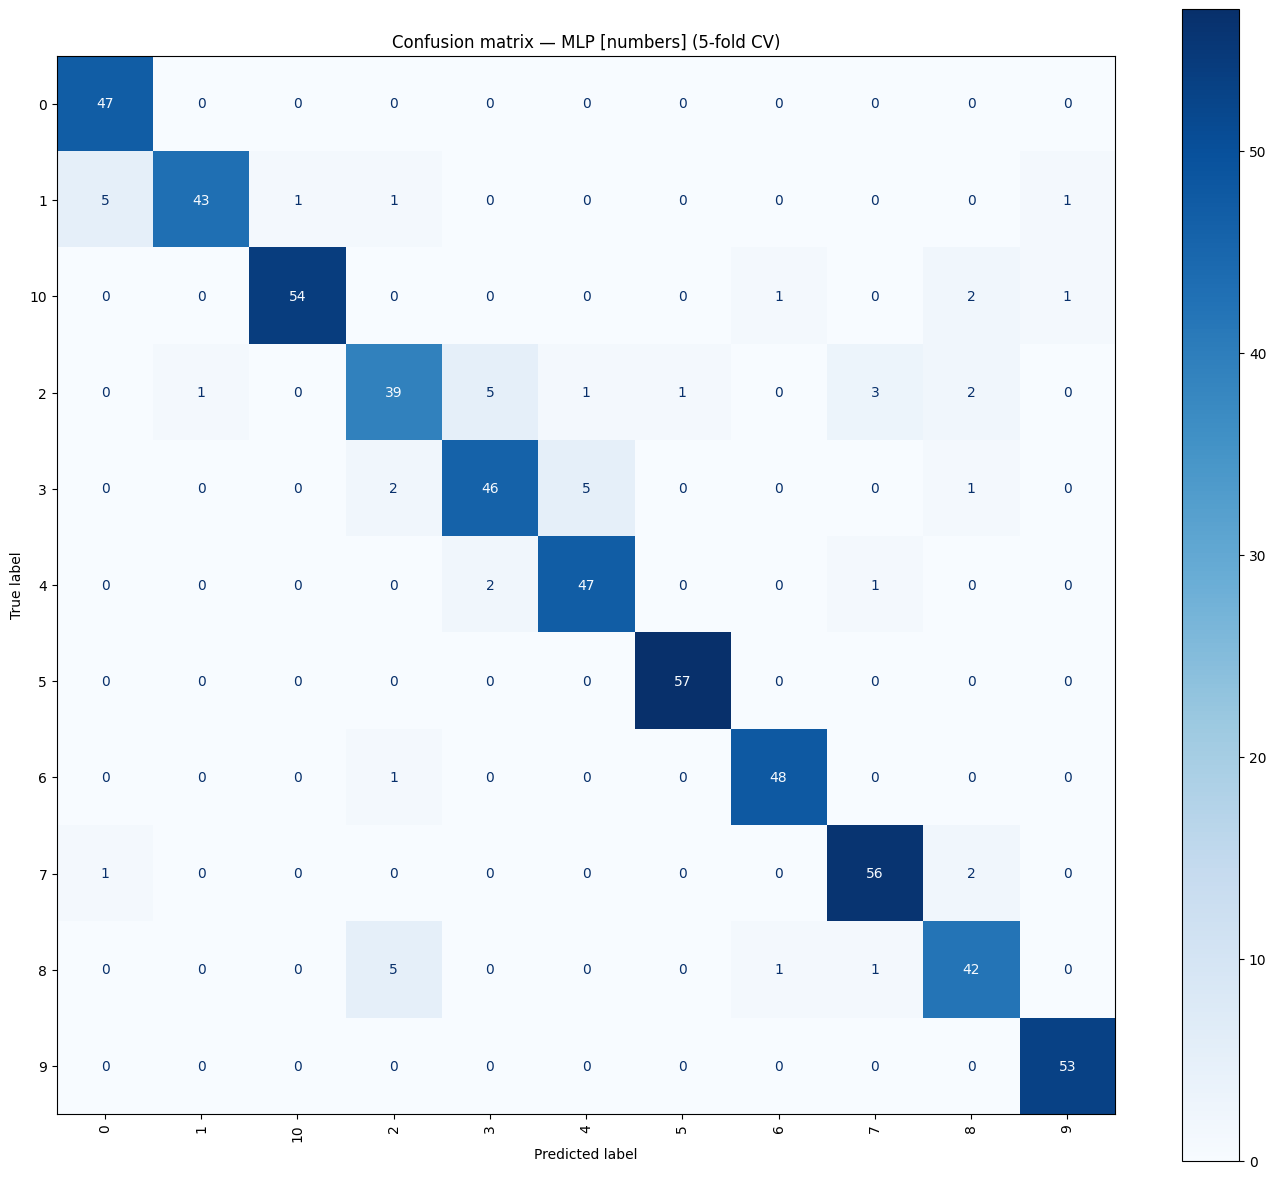

Saved: models/MLP_numbers.pkl

  MODEL: XGBoost  |  task: NUMBERS
Train accuracy : 1.0000
Test  accuracy : 0.8534
Overfit gap    : 0.1466

Test classification report:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         9
           1       0.69      0.90      0.78        10
          10       0.91      0.83      0.87        12
           2       0.88      0.70      0.78        10
           3       0.69      0.82      0.75        11
           4       0.80      0.80      0.80        10
           5       1.00      1.00      1.00        11
           6       1.00      1.00      1.00        10
           7       0.91      0.83      0.87        12
           8       0.90      0.90      0.90        10
           9       1.00      0.91      0.95        11

    accuracy                           0.85       116
   macro avg       0.86      0.85      0.85       116
weighted avg       0.86      0.85      0.86       116

── 5-Fold CV ──
  S

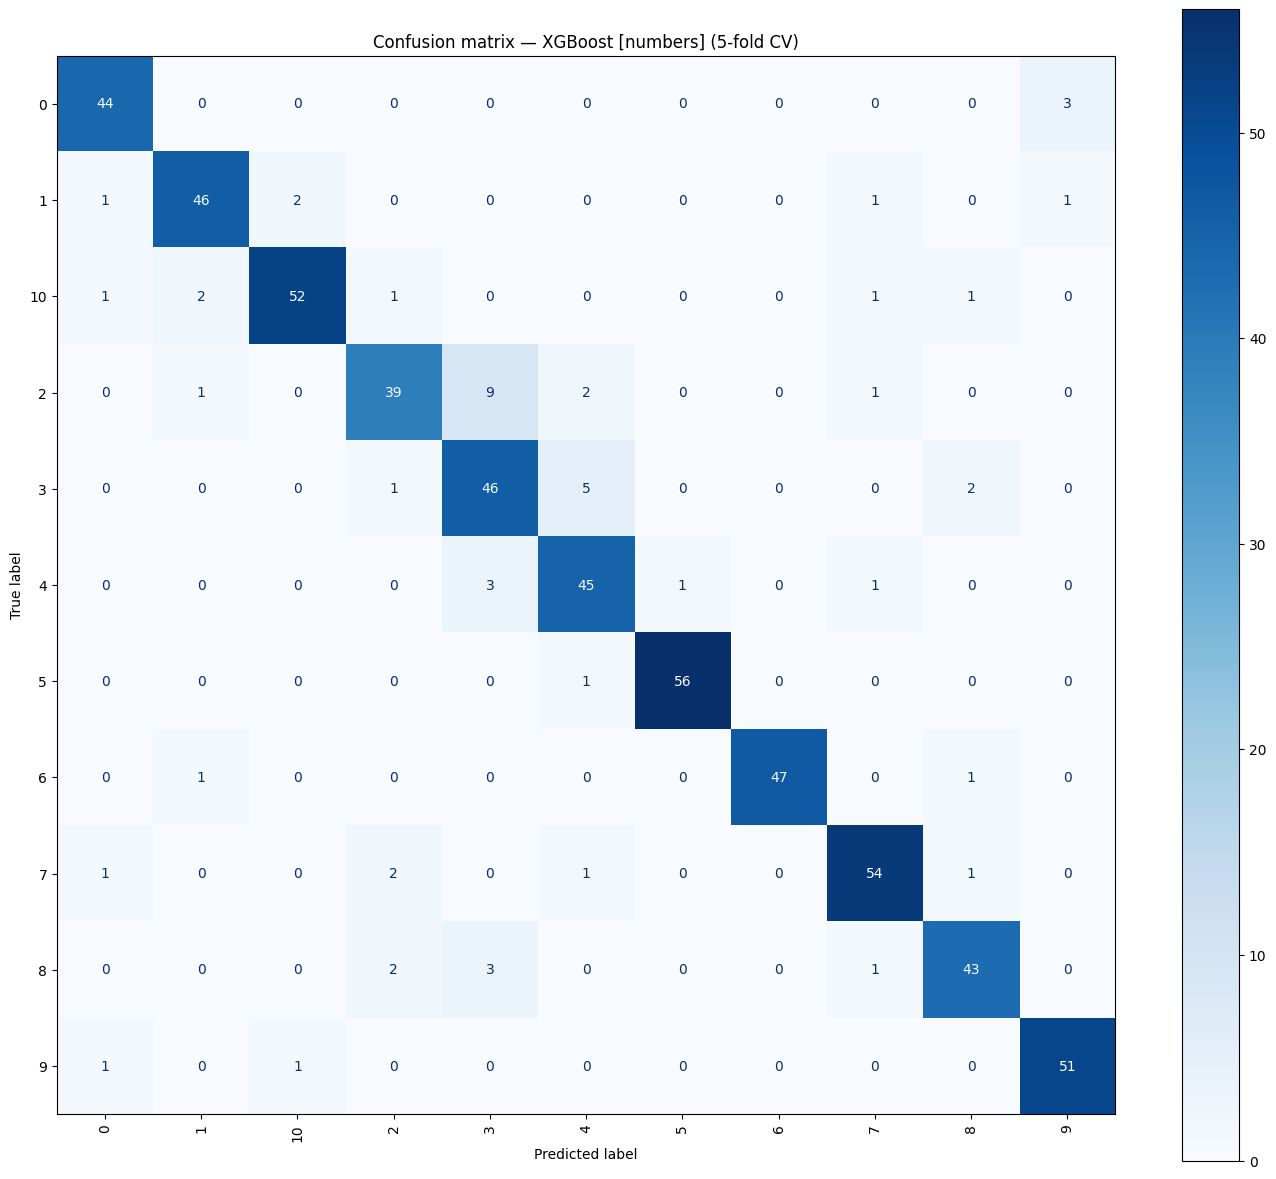

Saved: models/XGBoost_numbers.pkl

── Inference speed (single sample, 200 runs) ──
Model                    ms/pred       FPS
--------------------------------------------
  RandomForest          44.387 ms      22.5
  MLP                    0.708 ms    1411.6
  XGBoost                0.888 ms    1126.5

── Results summary — numbers ──
Model                   Train     Test    CV Mean    CV Std
----------------------------------------------------------
  RandomForest         0.9849   0.8793     0.9050    0.0213
  MLP                  0.9957   0.8879     0.9188    0.0334
  XGBoost              1.0000   0.8534     0.9033    0.0291


In [6]:
numbers_results = run_task(
    X_numbers, y_numbers, numbers_encoder,
    task="numbers", models_dict=numbers_models
)